In [47]:
# Member 1: EDA + Logistic Regression
# Step 2: Loading the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nice plots
plt.style.use('default')
sns.set_style("whitegrid")

print("✅ Libraries imported successfully!")

# Load the dataset
# Exact location: data/credit_risk_dataset.csv
df = pd.read_csv('../data/credit_risk_preprocessed.csv')

print("✅ Dataset loaded successfully!")

✅ Libraries imported successfully!
✅ Dataset loaded successfully!


In [48]:
# Step 3: Basic information about the dataset

print("=== Basic Dataset Information ===")

# 1. Shape of the dataset (number of rows and columns)
print(f"Number of rows (customers): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== First 5 rows of data ===")
display(df.head())

print("\n=== Last 5 rows of data ===")
display(df.tail())

=== Basic Dataset Information ===
Number of rows (customers): 32581
Number of columns (features): 23

=== Column Names ===
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']

=== First 5 rows of data ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True



=== Last 5 rows of data ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
32576,57,53000,1.0,5800,13.16,0,0.11,30,False,False,...,False,True,False,False,True,False,False,False,False,False
32577,54,120000,4.0,17625,7.49,0,0.15,19,False,False,...,False,True,False,False,False,False,False,False,False,False
32578,65,76000,3.0,35000,10.99,1,0.46,28,False,False,...,False,False,False,True,False,False,False,False,False,False
32579,56,150000,5.0,15000,11.48,0,0.10,26,False,False,...,False,True,False,True,False,False,False,False,False,False
32580,66,42000,2.0,6475,9.99,0,0.15,30,False,False,...,True,False,False,True,False,False,False,False,False,False


In [49]:
# Step 4: Data types and missing values

print("=== Data Types of Each Column ===")
print(df.dtypes)

print("\n=== Missing Values Check ===")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent.round(2)
})

print(missing_table)

# Highlight columns that have missing values
print("\nColumns with missing values:")
print(missing_table[missing_table['Missing Values'] > 0])

=== Data Types of Each Column ===
person_age                       int64
person_income                    int64
person_emp_length              float64
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_cred_hist_length       int64
person_home_ownership_OTHER       bool
person_home_ownership_OWN         bool
person_home_ownership_RENT        bool
loan_intent_EDUCATION             bool
loan_intent_HOMEIMPROVEMENT       bool
loan_intent_MEDICAL               bool
loan_intent_PERSONAL              bool
loan_intent_VENTURE               bool
loan_grade_B                      bool
loan_grade_C                      bool
loan_grade_D                      bool
loan_grade_E                      bool
loan_grade_F                      bool
loan_grade_G                      bool
cb_person_default_on_file_Y       bool
dtype: object

=== Missing Values Check ===
                         

In [50]:
# Step 5: Summary statistics for numerical columns

print("=== Summary Statistics for Numerical Features ===")
display(df.describe())

# Also show summary for the target variable 'loan_status'
print("\n=== Target Variable Distribution (loan_status) ===")
print(df['loan_status'].value_counts())
print("\nPercentage:")
print(df['loan_status'].value_counts(normalize=True).round(4) * 100)

=== Summary Statistics for Numerical Features ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



=== Target Variable Distribution (loan_status) ===
loan_status
0    25473
1     7108
Name: count, dtype: int64

Percentage:
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64


✅ Output folders created/checked successfully!


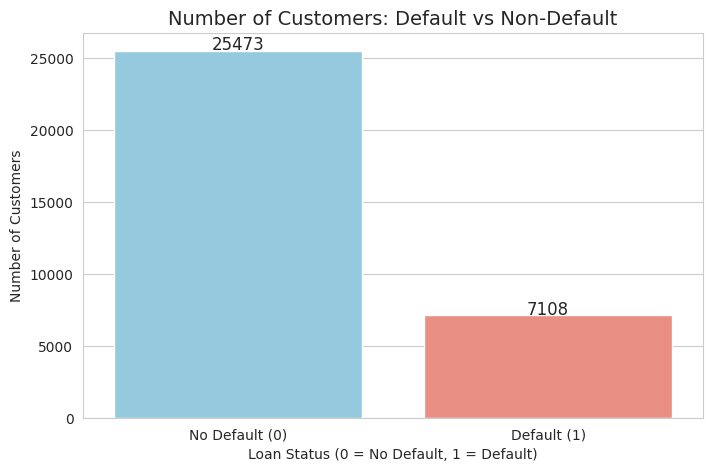

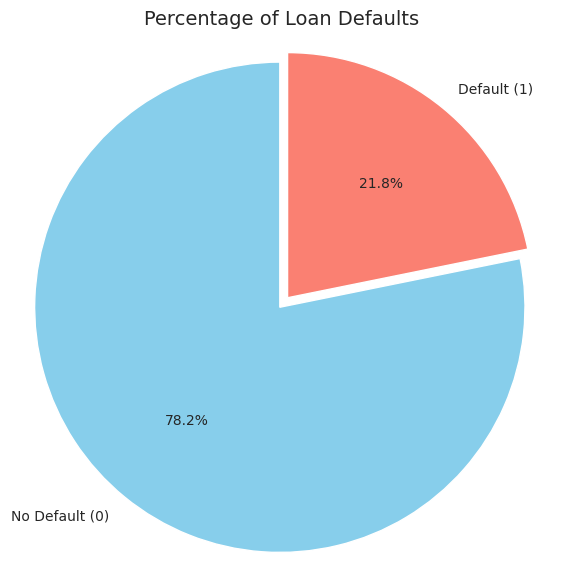

✅ Plots saved successfully!
Total customers: 32581
No Default (0): 25473 (78.2%)
Default (1): 7108 (21.8%)


In [51]:
# Step 6: Visualizing the Target Variable (loan_status) - FIXED with folder creation

import os

# Create the outputs/plots folder if it doesn't exist
os.makedirs('../outputs/plots', exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)

print("✅ Output folders created/checked successfully!")

# Count the number of defaults and non-defaults
target_counts = df['loan_status'].value_counts()

# 1. Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, 
            hue=target_counts.index, 
            palette=['skyblue', 'salmon'], 
            legend=False)
plt.title('Number of Customers: Default vs Non-Default', fontsize=14)
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])

# Add value labels on top of bars
for i, count in enumerate(target_counts.values):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12)

# Save plot - correct path from notebooks/
plt.savefig('../outputs/plots/member1_target_distribution_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(target_counts.values, 
        labels=['No Default (0)', 'Default (1)'],
        autopct='%1.1f%%',
        colors=['skyblue', 'salmon'],
        startangle=90,
        explode=(0, 0.05))
plt.title('Percentage of Loan Defaults', fontsize=14)
plt.axis('equal')

plt.savefig('../outputs/plots/member1_target_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plots saved successfully!")
print(f"Total customers: {len(df)}")
print(f"No Default (0): {target_counts.get(0, 0)} ({target_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"Default (1): {target_counts.get(1, 0)} ({target_counts.get(1, 0)/len(df)*100:.1f}%)")

=== Visualizing Numerical Features ===


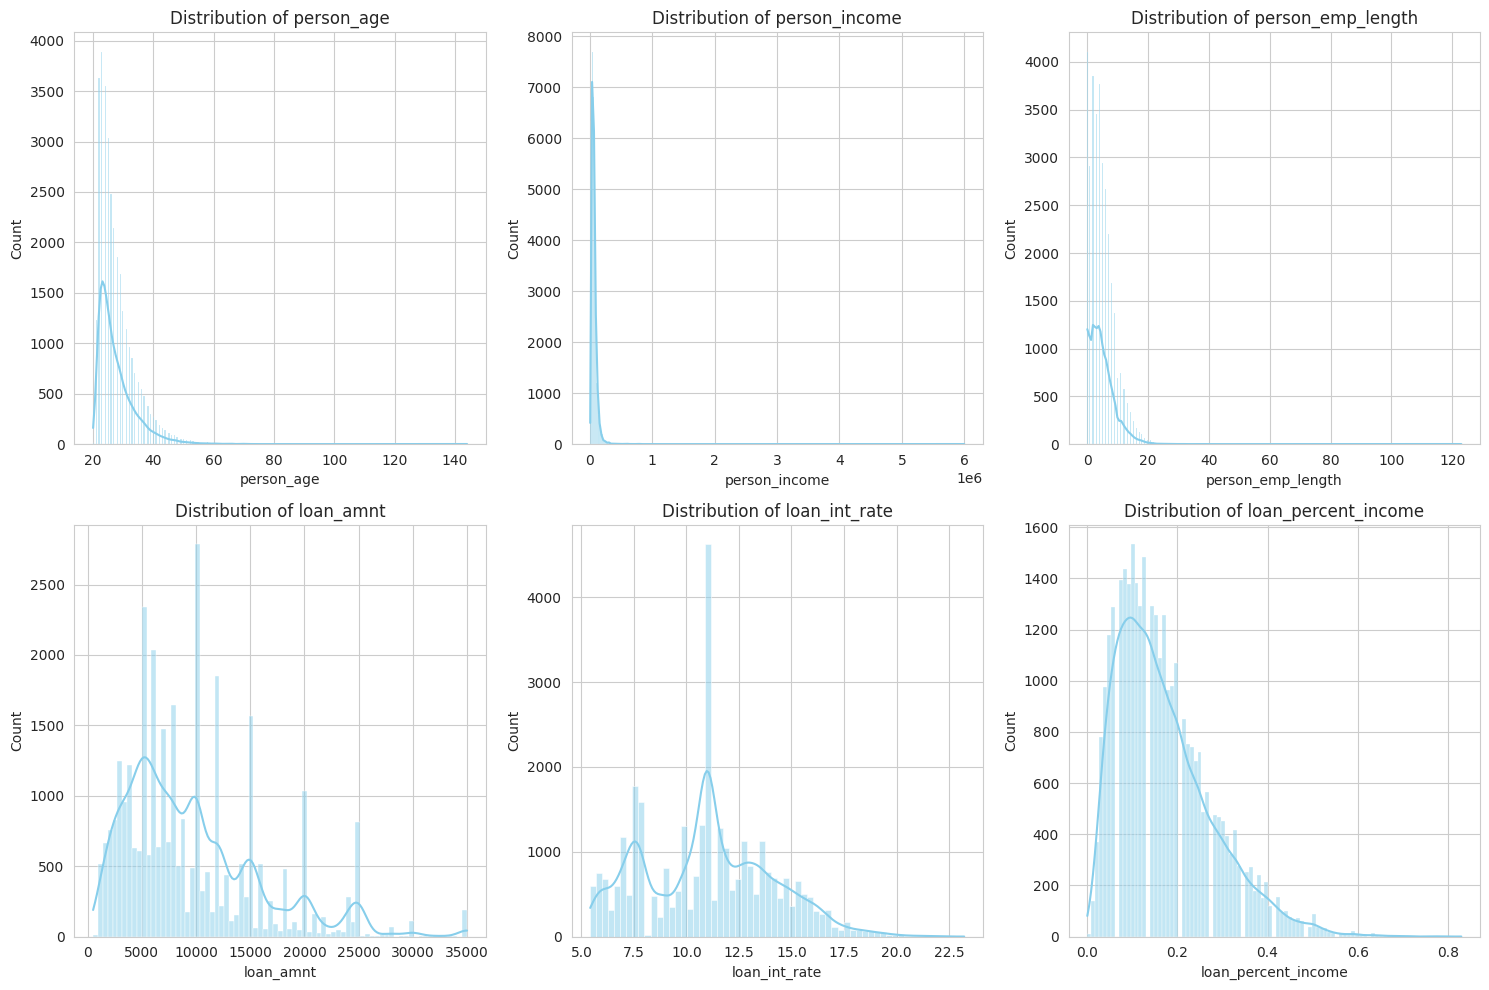

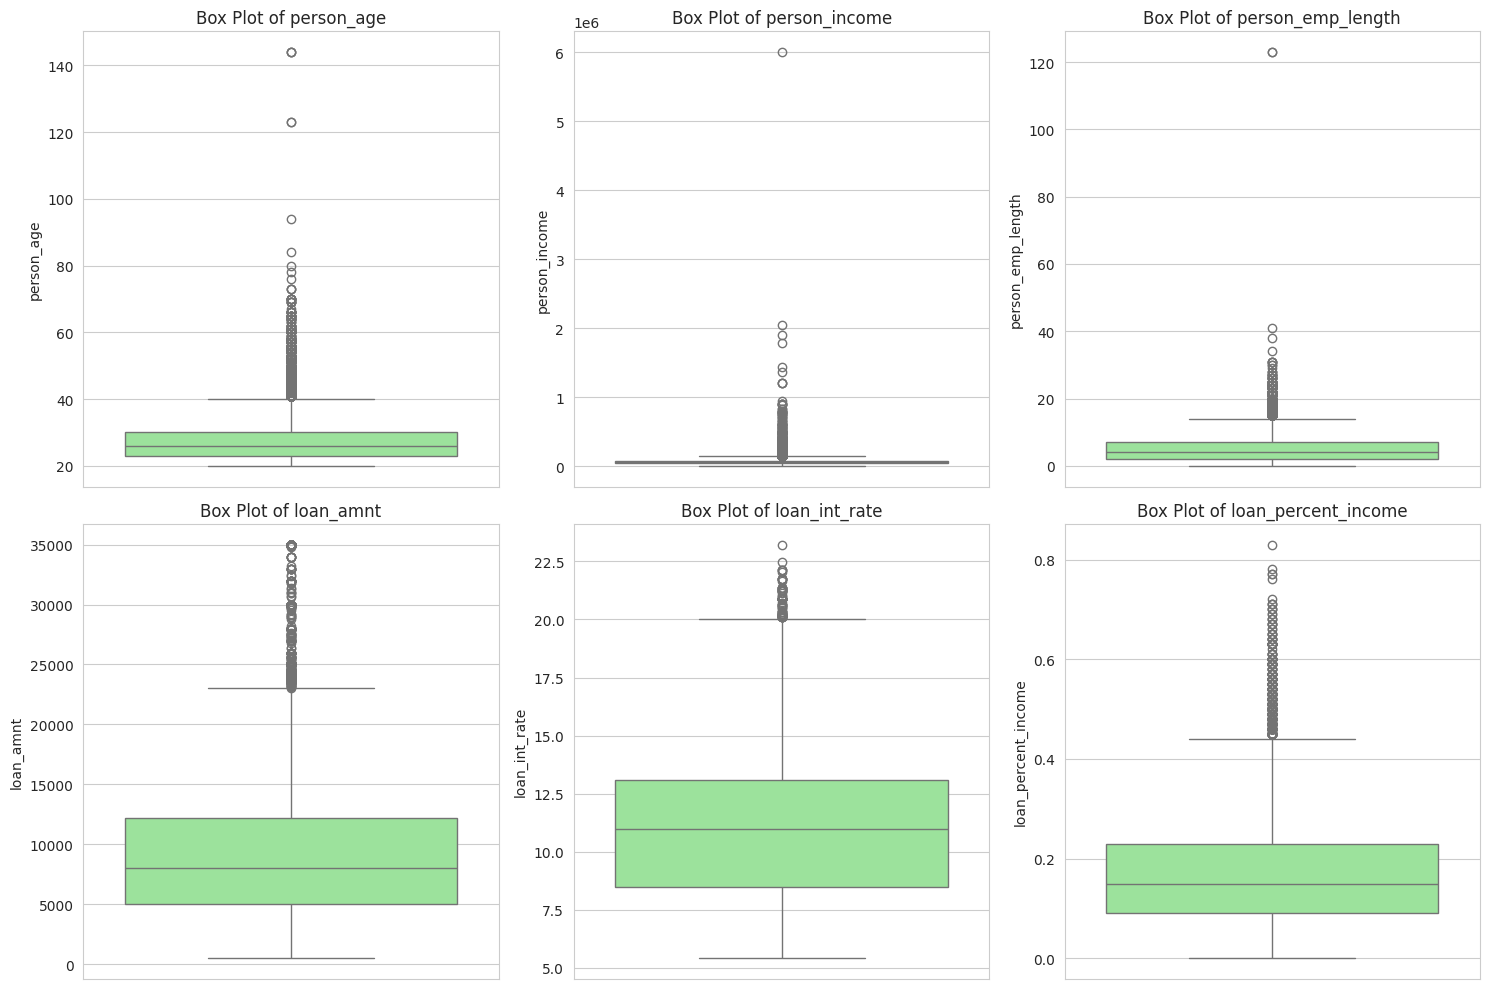

✅ Numerical feature plots saved in outputs/plots/


In [52]:
# Step 7: Visualizing Numerical Features - Histograms and Box Plots

# First, make sure output folder exists
import os
os.makedirs('../outputs/plots', exist_ok=True)

numerical_cols = ['person_age', 'person_income', 'person_emp_length', 
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income']

print("=== Visualizing Numerical Features ===")

# Histograms (distribution)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.savefig('../outputs/plots/member1_numerical_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# Box plots (to see outliers and spread)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.savefig('../outputs/plots/member1_numerical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Numerical feature plots saved in outputs/plots/")

=== Visualizing Categorical Features ===


ValueError: Could not interpret value `person_home_ownership` for `x`. An entry with this name does not appear in `data`.

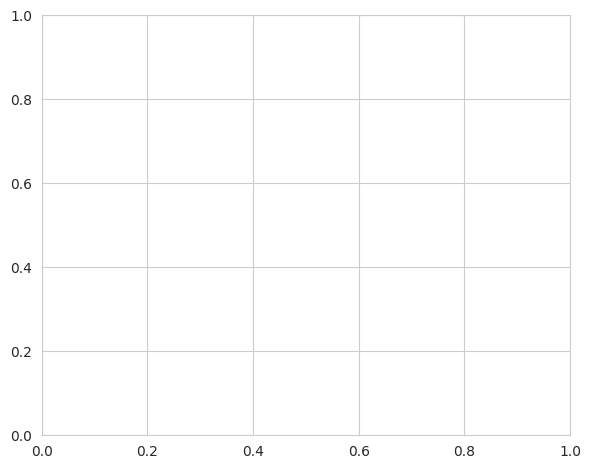

In [53]:
# Step 8: Visualizing Categorical Features

import os
os.makedirs('../outputs/plots', exist_ok=True)

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

print("=== Visualizing Categorical Features ===")

# Create count plots for each categorical column
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, hue='loan_status', palette=['skyblue', 'salmon'])
    plt.title(f'Distribution of {col} by Loan Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Loan Status', labels=['No Default (0)', 'Default (1)'])

plt.tight_layout()
plt.savefig('../outputs/plots/member1_categorical_countplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Categorical feature plots saved in outputs/plots/")

# Also print value counts for each categorical column
for col in categorical_cols:
    print(f"\n=== Value counts for {col} ===")
    print(df[col].value_counts())
    print("\nBy loan_status:")
    print(pd.crosstab(df[col], df['loan_status'], normalize='index').round(3) * 100)

=== Correlation Analysis ===


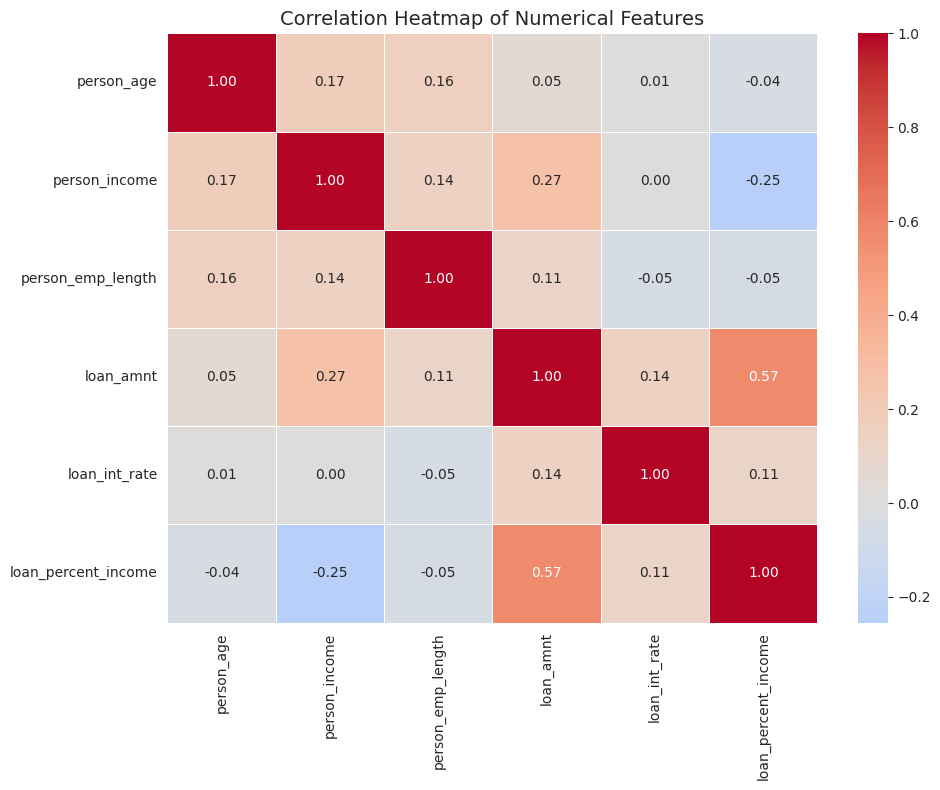

✅ Correlation heatmap saved in outputs/plots/

=== Average Values by Loan Status (0 = No Default, 1 = Default) ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
loan_status,,,,,,
0,27.81,70804.36,4.95,9237.46,10.49,0.15
1,27.47,49125.65,4.13,10850.50,12.87,0.25



✅ Table saved as CSV in outputs/results/


In [54]:
# Step 9: Correlation Heatmap and Relationship with Target

import os
os.makedirs('../outputs/plots', exist_ok=True)

print("=== Correlation Analysis ===")

# Select only numerical columns for correlation
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income']

# Create correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/plots/member1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved in outputs/plots/")

# Relationship of numerical features with target (mean values)
print("\n=== Average Values by Loan Status (0 = No Default, 1 = Default) ===")
mean_by_status = df.groupby('loan_status')[numerical_cols].mean().round(2)
display(mean_by_status)

# Save this table as image for report (optional but good for marks)
mean_by_status.to_csv('../outputs/results/member1_mean_by_loan_status.csv')

print("\n✅ Table saved as CSV in outputs/results/")

In [55]:
# Step 10: Building Logistic Regression Model (Baseline) - FIXED for missing values

print("=== Starting Logistic Regression Model (Baseline) ===")

# Select numerical features
numerical_features = ['person_age', 'person_income', 'person_emp_length', 
                      'loan_amnt', 'loan_int_rate', 'loan_percent_income']

# Create a copy and drop rows with missing values (simple handling for baseline)
X = df[numerical_features].copy()
y = df['loan_status'].copy()

# Drop rows where any feature is missing
data_clean = pd.concat([X, y], axis=1).dropna()
X_clean = data_clean[numerical_features]
y_clean = data_clean['loan_status']

print(f"Original rows: {len(df)}")
print(f"Rows after removing missing values: {len(X_clean)}")
print(f"Rows dropped: {len(df) - len(X_clean)}")

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, 
                                                    test_size=0.2, 
                                                    random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Train the Logistic Regression model
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully on clean data!")

=== Starting Logistic Regression Model (Baseline) ===
Original rows: 32581
Rows after removing missing values: 32581
Rows dropped: 0
Training samples: 26064
Testing samples: 6517
✅ Logistic Regression model trained successfully on clean data!


=== Evaluating Logistic Regression Model ===
Accuracy: 0.8235 (82.35%)

=== Classification Report ===
                precision    recall  f1-score   support

No Default (0)       0.84      0.95      0.89      5072
   Default (1)       0.70      0.36      0.48      1445

      accuracy                           0.82      6517
     macro avg       0.77      0.66      0.69      6517
  weighted avg       0.81      0.82      0.80      6517


=== Confusion Matrix ===
[[4843  229]
 [ 921  524]]


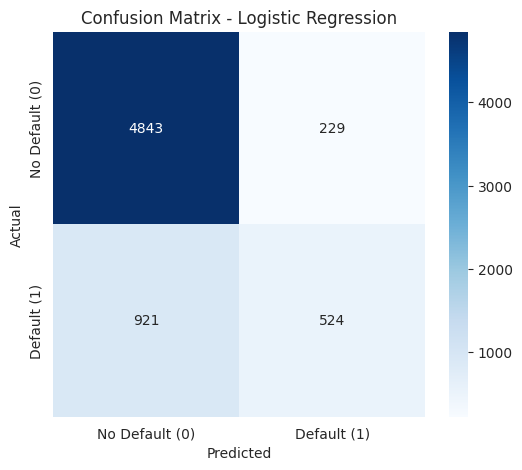


✅ Evaluation completed! Plot saved in outputs/plots/


In [56]:
# Step 11: Making Predictions and Basic Evaluation of Logistic Regression

print("=== Evaluating Logistic Regression Model ===")

# Make predictions on the test set
y_pred = model_lr.predict(X_test)
y_pred_proba = model_lr.predict_proba(X_test)[:, 1]  # Probability of default (class 1)

# Calculate basic metrics
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Default (0)', 'Default (1)']))

# Confusion Matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../outputs/plots/member1_confusion_matrix_lr.png', dpi=300, bbox_inches='tight')
plt.show()

# Save model results for later comparison
results = {
    'Model': 'Logistic Regression (Baseline)',
    'Accuracy': round(accuracy, 4),
    'Rows Used': len(X_clean)
}

print("\n✅ Evaluation completed! Plot saved in outputs/plots/")

In [57]:
# Step 12: Saving the Model and Creating Summary for Report

import os
import joblib

os.makedirs('../models', exist_ok=True)

print("=== Saving Model and Creating Summary ===")

# 1. Save the trained Logistic Regression model
model_path = '../models/logistic_regression_model.pkl'
joblib.dump(model_lr, model_path)
print(f"✅ Model saved at: {model_path}")

# 2. Create a simple text summary (you can copy this into the report)
summary = f"""
MEMBER 1 CONTRIBUTION - EDA + LOGISTIC REGRESSION

1. EXPLORATORY DATA ANALYSIS (EDA):
   - Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns
   - Target Variable (loan_status): {df['loan_status'].value_counts()[0]} No Default ({df['loan_status'].value_counts(normalize=True)[0]*100:.1f}%)
                                 {df['loan_status'].value_counts()[1]} Default ({df['loan_status'].value_counts(normalize=True)[1]*100:.1f}%)
   - Visualizations created:
     • Target distribution (bar + pie)
     • Numerical features: Histograms + Box plots
     • Categorical features: Count plots by loan status
     • Correlation heatmap
   - Key Insights:
     • Dataset is imbalanced (more non-defaults)
     • loan_percent_income and loan_int_rate positively correlated with default
     • Higher income generally lowers default risk
     • RENT home ownership and lower loan grades show higher default rates

2. LOGISTIC REGRESSION MODEL (Baseline):
   - Features used: Numerical columns only
   - Rows after removing missing values: {len(X_clean)}
   - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)
   - Model saved as: logistic_regression_model.pkl

3. Files Created by Member 1:
   - Notebook: notebooks/member1_eda_logistic.ipynb
   - Plots in: outputs/plots/ (target, histograms, boxplots, categorical, correlation, confusion matrix)
   - Results in: outputs/results/
"""

print(summary)

# Save the summary as a text file for easy copy-paste into report
with open('../outputs/results/member1_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✅ Summary saved as: outputs/results/member1_summary.txt")
print("✅ You can copy the summary above directly into your final report!")

=== Saving Model and Creating Summary ===
✅ Model saved at: ../models/logistic_regression_model.pkl

MEMBER 1 CONTRIBUTION - EDA + LOGISTIC REGRESSION

1. EXPLORATORY DATA ANALYSIS (EDA):
   - Dataset Shape: 32581 rows, 23 columns
   - Target Variable (loan_status): 25473 No Default (78.2%)
                                 7108 Default (21.8%)
   - Visualizations created:
     • Target distribution (bar + pie)
     • Numerical features: Histograms + Box plots
     • Categorical features: Count plots by loan status
     • Correlation heatmap
   - Key Insights:
     • Dataset is imbalanced (more non-defaults)
     • loan_percent_income and loan_int_rate positively correlated with default
     • Higher income generally lowers default risk
     • RENT home ownership and lower loan grades show higher default rates

2. LOGISTIC REGRESSION MODEL (Baseline):
   - Features used: Numerical columns only
   - Rows after removing missing values: 32581
   - Accuracy: 0.8235 (82.35%)
   - Model saved